In [129]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import gc
from scipy.sparse import eye, hstack, vstack, csr_matrix, identity
import statsmodels.api as sm
import math
import gurobipy as gp
from gurobipy import GRB
import seaborn as sns
from matplotlib import colors as mcolors
from matplotlib.patches import Patch

np.set_printoptions(precision=9, floatmode='fixed', suppress=True)


In [130]:
# Input data ------------------------------------------------------------------------------------------------
start='2019-01-01'                  # Start data
end= '2022-01-01'                   # End data

index = 1                           # American_market_SP500_'^GSPC' --> 1 or Brazilian_Market_Ibovespa_'^BVSP' --> 2
T = 252                         # number of training days
#R = 63                        # number of days for the rebalancing period
psi_list = [0.2, 0.5, 0.8]          # regularization psi values
matriz_Q = 1                        # cov^-0.5 --> 1, eye --> 2, Whitening --> 3
gamma = 1                           # Risk aversion coef
cut = 1e-6                          # Precision alphas
regularization = 1e-3               # Regularization matrix
alpha_var = 0                   # Confidence level: VaR and CVaR
confidence_level = int(alpha_var*100)    # Confidence level (%)

risk_free_rate = 0
threshold = 0.10
#  -------------------------------------------------------------------------------------------------------
colors_svc = ['#9ca09a', '#6a7168', '#30302f']
def get_colors(num_methods):
    if num_methods <= 3:
        return colors_svc[:num_methods]
    else:
        additional_colors = plt.cm.viridis(np.linspace(0, 1, num_methods - 3))
        return colors_svc + [mcolors.rgb2hex(c) for c in additional_colors]

num_methods = len(psi_list)
colors_svc = get_colors(num_methods)

cores_personalizadas = ['lightblue', 'salmon', '#9ca09a', '#6a7168', '#30302f']
cores = {0.2: '#9ca09a', 0.5: '#6a7168', 0.8: '#30302f'}
cor_0_2 = list(cores.keys())[0]
cor1 = cores[cor_0_2]
cor_0_5 = list(cores.keys())[1]
cor2 = cores[cor_0_5]
cor_0_8 = list(cores.keys())[2]
cor3 = cores[cor_0_8]

In [131]:
#### --------------------------------------------------------------------------
## Comodities
symbol_index = '^BCOM'
hist_index = yf.download(symbol_index, start=start, end=end)['Close']
retornos_indices = hist_index.pct_change()

tickers = [
    'ZS=F',  # Soja
    'ZC=F',  # Milho
    'KC=F',  # Café
    'SB=F',  # Açúcar
    'CT=F',  # Algodão
    'ZW=F',  # Trigo
    'LE=F',  # Boi gordo
    'HE=F',  # Porco
    'TIO=F', # Minério de ferro
    'CL=F',  # Petróleo WTI
    'BZ=F',  # Brent
    'ALI=F', # Alumínio
    'GC=F'   # Ouro
]

                   
data = yf.download(tickers, start, end)['Close']
data_clean = data.dropna(axis=1)
data_clean = data_clean.dropna()
retornos_ativos = data_clean.pct_change().dropna()
# ------------------------------------------------------------------------------------------------ 

## Dataframe completo: datas / retornos / indice
retornos_indices = retornos_indices.tz_localize(None)
dados_completos = retornos_ativos.join(retornos_indices)
df = pd.DataFrame(dados_completos)

df_assets = df.iloc[:, :-1]  # dados completos 
df_bench = df.iloc[:,-1]
num_returns_total, num_assets_total = df_assets.shape

/var/folders/87/ynv0vm3x3w3_xj6zkm4nkw_40000gn/T/ipykernel_39158/1080792348.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hist_index = yf.download(symbol_index, start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/87/ynv0vm3x3w3_xj6zkm4nkw_40000gn/T/ipykernel_39158/1080792348.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start, end)['Close']
[*********************100%***********************]  13 of 13 completed


In [132]:
print(df_assets.head())

Ticker      ALI=F      BZ=F      CL=F      CT=F      GC=F      HE=F      KC=F  \
Date                                                                            
2019-01-03    0.0  0.018940  0.011818 -0.000141  0.008431  0.007293  0.026633   
2019-01-04    0.0  0.019839  0.018475  0.023860 -0.007045 -0.003218 -0.005384   
2019-01-07    0.0  0.004732  0.011676  0.003172  0.003196 -0.000807  0.011319   
2019-01-08    0.0  0.024246  0.025969 -0.014845 -0.002798  0.011309  0.022384   
2019-01-09    0.0  0.046321  0.051828  0.020371  0.004754  0.018770  0.002380   

Ticker          LE=F      SB=F     TIO=F      ZC=F      ZS=F      ZW=F  
Date                                                                    
2019-01-03 -0.002429 -0.020117  0.016465  0.010645  0.006147  0.013814  
2019-01-04 -0.010550  0.020530  0.011906  0.008558  0.010275  0.006326  
2019-01-07  0.010457  0.060352  0.014503 -0.001958  0.003024 -0.000484  
2019-01-08  0.017046  0.008696  0.000809 -0.005886 -0.006577  0.001

In [133]:
print(df_bench.head())

Date
2019-01-03    0.005975
2019-01-04    0.011491
2019-01-07    0.002936
2019-01-08    0.004836
2019-01-09    0.012160
Name: ^BCOM, dtype: float64


<!-- -->

In [134]:
# SOLVER: GUROBI -------------------------------------------------------------
def calculate_mk_optimum_weights(returns, gamma):
    returns_np = np.array(returns)
    num_returns, num_assets = returns.shape
    mu = np.mean(returns_np, axis=0)
    cov_matrix = np.cov(returns_np, rowvar=False)
    P = gamma*cov_matrix
    q = mu
    model = gp.Model()
    w = model.addMVar(shape=num_assets, lb=0, ub=1, name="w")
    objective = -w @ P @ w + q.T @ w
    model.setObjective(objective, GRB.MAXIMIZE)
    model.addConstr(w.sum() == 1, "c0")
    model.optimize()
    if model.status == GRB.OPTIMAL:
        print("Status MK: Optimal")
        return w.x
    else:
        print(f"Status MK: {model.status}")
        return None

In [135]:

## Gram matrix (WGI) -----------------------------------------------------------
def calculate_wgi_kernel(num_returns, df_assets_np, Q):
    lk_const = 1.3
    product_Q_return = np.dot(Q.T, df_assets_np.T)
    l = lk_const * (np.max(product_Q_return, axis=1) - np.min(product_Q_return, axis=1))
    l_sum = np.sum(l)
    K = np.zeros((num_returns, num_returns))
    for i in range(num_returns):
        diff_return = df_assets_np - df_assets_np[i, :]
        K[i, :] = l_sum - np.linalg.norm(np.dot(Q, diff_return.T), ord=1, axis=0)
    return K

## Precision alphas: SVS, BSVS, IDS -------------------------------------------------
def adjust_alpha_values(x_values, limit_alpha, cut):
    for i in range(len(x_values)):
        if x_values[i] <= cut:
            x_values[i] = 0
        elif np.abs(x_values[i] - limit_alpha) < cut:
            x_values[i] = limit_alpha
    return x_values

## -----------------------------------------------------------------------------------
# OPTIMIZATION SVC
## -----------------------------------------------------------------------------------
def calculate_svc_optimum_weights(returns, gamma, psi):
    num_returns, num_assets= returns.shape
    returns_np = np.array(returns)
    cov_matrix = np.cov(returns, rowvar=False)

    # Matriz Q ------------------------------------------------------------------------
    if matriz_Q == 1:
        cov_matrix = np.cov(returns_np, rowvar=False)
        U, S, Vt = np.linalg.svd(cov_matrix)
        Q = np.dot(U, np.diag(1.0 / np.sqrt(S))).dot(Vt)
    elif matriz_Q == 2:
        Q = np.eye(num_assets)
    elif matriz_Q==3:
        returns_np_centered = returns_np - np.mean(returns_np, axis=0)
        cov_matrix_centered = np.cov(returns_np_centered, rowvar=False)
        U, S, Vt = np.linalg.svd(cov_matrix_centered)
        Q = np.dot(U, np.diag(1.0 / np.sqrt(S + cut))).dot(U.T)
    else:
        print("Error: Q matrix")
        exit()


    # Matriz K -----------------------------------------------------------------------
    K = calculate_wgi_kernel(num_returns, returns_np, Q)


    # GUROBI OPTIMIZATION: uncertatin set---------------------------------------------
    limite_alpha=1/(num_returns*psi)
    P=K
    q=np.diagonal(K)
    model = gp.Model()
    x = model.addMVar(shape=num_returns, lb=0, ub=limite_alpha, name="Uncertainty")
    objective =  -x @ P @ x + q @ x
    model.setObjective(objective, GRB.MAXIMIZE)
    model.addConstr(x.sum() == 1)
    model.optimize()
    if model.status == GRB.OPTIMAL:
        solution = x.X
        print("Optimal solution - SVC (WGI) part 1:", solution)
    else:
        print("No optimal solution found - SVC (WGI) part 1")
    x_values=solution


    # Rounding of alphas ---------------------------------------------------------------
    x_adjust = adjust_alpha_values(x_values, limite_alpha, cut)
    svs = np.where(x_adjust > 0)[0]
    bsvs = np.where((x_adjust > 0) & (x_adjust < limite_alpha))[0]
    n_svs = svs.size
    n_bsvs = bsvs.size
    returns_np_bsvs = returns_np[bsvs]
    returns_np_svs = returns_np[svs]


    # Theta parameter -------------------------------------------------------------------
    thetas = np.zeros(n_bsvs)
    for j in range(n_bsvs):
        theta = 0
        for i in range(n_svs):
            theta += x_adjust[i] * np.linalg.norm(Q @ (returns_np_bsvs[j, :] - returns_np_svs[i, :]), ord=1)
        thetas[j] = theta
    theta_min_ = np.min(thetas)
    theta_min=theta_min_*np.ones(1)


    # GUROBI OPTIMIZATION: weights -------------------------------------------------------
    n_var = 2*n_svs*num_assets+num_assets+1


    # Quadratical term-------------------------------------------------------------------
    cov_complet = csr_matrix((num_assets, n_var - num_assets))
    sparse_top = hstack([csr_matrix(cov_matrix), cov_complet])
    sparse_bottom = csr_matrix((n_var - num_assets, n_var))
    P = gamma * vstack([sparse_top, sparse_bottom]).tocsc()


    # Linear term-------------------------------------------------------------------------
    aux_q1=csr_matrix(np.zeros((num_assets, 1)))
    result_list = []
    for i in range(n_svs):
        result = np.dot(returns_np_svs[i, :], Q)
        result_list.append(result.flatten())
    auxiliary = np.concatenate(result_list)
    auxiliary=np.array([auxiliary]).reshape(-1, 1)
    arr = np.array([theta_min])
    theta_min = arr.reshape(1, 1)
    q=vstack([aux_q1, theta_min, -auxiliary, +auxiliary], dtype=np.float32)


    # Equality constraints --------------------------------------------------------------
    repet_Q=np.kron(np.ones((1, n_svs)), Q)
    A2 = np.hstack((np.eye(num_assets), np.zeros((num_assets, 1)), -np.array(repet_Q), np.array(repet_Q)))
    b2 = np.zeros(num_assets)
    alphas_svs = x_adjust[svs]
    repeated_alphas = np.repeat(alphas_svs, num_assets)
    A3_2 = csr_matrix(repeated_alphas).T
    A3_3 = eye(num_assets*n_svs, format='csr')
    b3 = np.zeros(num_assets*n_svs)
    part_1 = csr_matrix((num_assets*n_svs, num_assets))
    A3 = hstack([part_1, A3_2, -A3_3, -A3_3])
    A = vstack([A2, A3], dtype=np.float32).toarray()
    b = np.concatenate([b2, b3], dtype=np.float32)


    # Model call ------------------------------------------------------------------------
    P_regularized = P + regularization*identity(n_var, format = 'coo')
    model2 = gp.Model()
    x2 = model2.addMVar(shape=n_var, lb=0, name="Portfolio")
    x2[:num_assets].ub = 1
    objective = -x2 @ P_regularized @ x2 - q.T @ x2
    model2.setObjective(objective, GRB.MAXIMIZE)
    model2.addConstr(x2[:num_assets].sum() == 1)
    model2.addConstr(A @ x2 == b)
    model2.optimize()

    if model2.status == GRB.OPTIMAL:
        solution2 = x2.X
        print("Optimal solution - SVC (WGI) part 2:", solution2)
    else:
        print("No optimal solution found - SVC (WGI) part 2")
    return solution2[:num_assets]

In [136]:
gc.collect()
R = 63

test = df_assets.iloc[T:]
training = df_assets[:T]

window_size = T
rebalancing_interval = R
num_rebal = math.ceil((num_returns_total - window_size)/rebalancing_interval)

cumulative_portfolio_returns_svc_dict = {psi: [] for psi in psi_list}
cumulative_portfolio_returns_equal=[]
cumulative_portfolio_returns_mk=[]
dates = []


diversity_svc_dict = {psi: [] for psi in psi_list}
diversity_mk = []


hhi_svc_dict = {psi: [] for psi in psi_list}
hhi_mk_list = []
hhi_equal_list = []


weights_svc_dict = {psi: [] for psi in psi_list}
weights_mk_list = []
weights_equal_list = []


turnover_svc_dict = {psi: [] for psi in psi_list}
turnover_mk = []
turnover_equal = []


previous_weights_svc = {psi: None for psi in psi_list}
previous_weights_mk = None
previous_weights_equal = None

print("Number of rebalancings/optimizations: ", num_rebal)

for i, start in enumerate(range(0, num_returns_total- window_size, rebalancing_interval)):
    end = start + window_size
    window_data = df_assets.iloc[start:end]
    num_periodos, num_assets = window_data.shape

    weights_svc={}
    for psi in psi_list:
        weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
    weights_mk = calculate_mk_optimum_weights(window_data, gamma)
    weights_equal = np.repeat(1/num_assets, num_assets)


    if previous_weights_mk is not None:
        for psi in psi_list:
            turnover_svc_dict[psi].append(np.sum(np.abs(weights_svc[psi] - previous_weights_svc[psi])))
        turnover_mk.append(np.sum(np.abs(weights_mk - previous_weights_mk)))
        turnover_equal.append(np.sum(np.abs(weights_equal - previous_weights_equal)))


    previous_weights_svc ={}
    for psi in psi_list:
        previous_weights_svc[psi] = weights_svc[psi]

    previous_weights_mk = weights_mk
    previous_weights_equal = weights_equal

    hhi_svc={}
    for psi in psi_list:
        hhi_svc[psi] = np.sum(weights_svc[psi]**2)
    hhi_mk = np.sum(weights_mk**2)
    hhi_equal = np.sum(weights_equal**2)

    num_assets_svc_rebal ={}
    for psi in psi_list:
        num_assets_svc_rebal[psi] = np.count_nonzero(weights_svc[psi]>cut)
    num_assets_mk_rebal = np.count_nonzero(weights_mk>cut)

    print(f"End of optimization {i+1} ----")

    next_period = df_assets.iloc[end:end + rebalancing_interval]
    if not next_period.empty:
        for psi in psi_list:
            weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
            portfolio_returns_svc = next_period.dot(weights_svc[psi])
            cumulative_portfolio_returns_svc_dict[psi].extend(portfolio_returns_svc)
            diversity_svc_dict[psi].append(num_assets_svc_rebal[psi])
            hhi_svc_dict[psi].append(hhi_svc[psi])
            weights_svc_dict[psi].append(weights_svc[psi])

        portfolio_returns_mk = next_period.dot(weights_mk)
        cumulative_portfolio_returns_mk.extend(portfolio_returns_mk)
        diversity_mk.append(num_assets_mk_rebal)
        hhi_mk_list.append(hhi_mk)
        weights_mk_list.append(weights_mk)

        portfolio_returns_equal = next_period.dot(weights_equal)
        cumulative_portfolio_returns_equal.extend(portfolio_returns_equal)
        hhi_equal_list.append(hhi_equal)
        weights_equal_list.append(weights_equal)

        dates.extend(next_period.index)


diversity_equal = np.repeat(num_assets, num_rebal)

cumulative_portfolio_returns_svc_series = {psi: [] for psi in psi_list}
cumulative_returns_svc = {psi: [] for psi in psi_list}
for psi in psi_list:
    cumulative_portfolio_returns_svc_series[psi] = pd.Series(cumulative_portfolio_returns_svc_dict[psi], index=dates)
    cumulative_returns_svc[psi] = (1 + cumulative_portfolio_returns_svc_series[psi]).cumprod() - 1

cumulative_portfolio_returns_equal_series = pd.Series(cumulative_portfolio_returns_equal, index=dates)
cumulative_return_equal = (1 + cumulative_portfolio_returns_equal_series).cumprod() - 1

cumulative_portfolio_returns_mk_series = pd.Series(cumulative_portfolio_returns_mk, index=dates)
cumulative_return_mk = (1 + cumulative_portfolio_returns_mk_series).cumprod() - 1

cumulative_return_bench= (1 + df_bench.iloc[window_size:]).cumprod() - 1

diversity_trimestral = pd.DataFrame({
    'SVC$_{0.2}$': diversity_svc_dict[0.2],
    'SVC$_{0.5}$': diversity_svc_dict[0.5],
    'SVC$_{0.8}$': diversity_svc_dict[0.8],
    'MK': diversity_mk,})
hhi_trimestral= pd.DataFrame({
    'SVC$_{0.2}$': hhi_svc_dict[0.2],
    'SVC$_{0.5}$': hhi_svc_dict[0.5],
    'SVC$_{0.8}$': hhi_svc_dict[0.8],
    'MK': hhi_mk_list,})
turnover_trimestral= pd.DataFrame({
    'SVC$_{0.2}$': turnover_svc_dict[0.2] ,
    'SVC$_{0.5}$': turnover_svc_dict[0.5] ,
    'SVC$_{0.8}$': turnover_svc_dict[0.8],
    'MK': turnover_mk,})

cumulative_returns_svc_trimestral = cumulative_returns_svc
cumulative_return_equal_trimestral = cumulative_return_equal
cumulative_return_mk_trimestral = cumulative_return_mk
cumulative_return_bench_trimestral = cumulative_return_bench

Number of rebalancings/optimizations:  8
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 252 columns and 252 nonzeros
Model fingerprint: 0x3e01b903
Model has 31878 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 2e+02]
  QObjective range [3e+02, 6e+02]
  Bounds range     [2e-02, 2e-02]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.00s
Presolved: 1 rows, 252 columns, 252 nonzeros
Presolved model has 31878 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 251
 AA' NZ     : 3.163e+04
 Factor NZ  : 3.188e+04 (roughly 1 MB of memory)
 Factor Ops : 5.366e+06 (less than 1 second per iteration)
 Threads    : 8

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Tim

In [137]:
gc.collect()
R = 126

test = df_assets.iloc[T:]
training = df_assets[:T]

window_size = T
rebalancing_interval = R
num_rebal = math.ceil((num_returns_total - window_size)/rebalancing_interval)

cumulative_portfolio_returns_svc_dict = {psi: [] for psi in psi_list}
cumulative_portfolio_returns_equal=[]
cumulative_portfolio_returns_mk=[]
dates = []


diversity_svc_dict = {psi: [] for psi in psi_list}
diversity_mk = []


hhi_svc_dict = {psi: [] for psi in psi_list}
hhi_mk_list = []
hhi_equal_list = []


weights_svc_dict = {psi: [] for psi in psi_list}
weights_mk_list = []
weights_equal_list = []


turnover_svc_dict = {psi: [] for psi in psi_list}
turnover_mk = []
turnover_equal = []


previous_weights_svc = {psi: None for psi in psi_list}
previous_weights_mk = None
previous_weights_equal = None

print("Number of rebalancings/optimizations: ", num_rebal)

for i, start in enumerate(range(0, num_returns_total- window_size, rebalancing_interval)):
    end = start + window_size
    window_data = df_assets.iloc[start:end]
    num_periodos, num_assets = window_data.shape

    weights_svc={}
    for psi in psi_list:
        weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
    weights_mk = calculate_mk_optimum_weights(window_data, gamma)
    weights_equal = np.repeat(1/num_assets, num_assets)


    if previous_weights_mk is not None:
        for psi in psi_list:
            turnover_svc_dict[psi].append(np.sum(np.abs(weights_svc[psi] - previous_weights_svc[psi])))
        turnover_mk.append(np.sum(np.abs(weights_mk - previous_weights_mk)))
        turnover_equal.append(np.sum(np.abs(weights_equal - previous_weights_equal)))


    previous_weights_svc ={}
    for psi in psi_list:
        previous_weights_svc[psi] = weights_svc[psi]

    previous_weights_mk = weights_mk
    previous_weights_equal = weights_equal

    hhi_svc={}
    for psi in psi_list:
        hhi_svc[psi] = np.sum(weights_svc[psi]**2)
    hhi_mk = np.sum(weights_mk**2)
    hhi_equal = np.sum(weights_equal**2)

    num_assets_svc_rebal ={}
    for psi in psi_list:
        num_assets_svc_rebal[psi] = np.count_nonzero(weights_svc[psi]>cut)
    num_assets_mk_rebal = np.count_nonzero(weights_mk>cut)

    print(f"End of optimization {i+1} ----")

    next_period = df_assets.iloc[end:end + rebalancing_interval]
    if not next_period.empty:
        for psi in psi_list:
            weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
            portfolio_returns_svc = next_period.dot(weights_svc[psi])
            cumulative_portfolio_returns_svc_dict[psi].extend(portfolio_returns_svc)
            diversity_svc_dict[psi].append(num_assets_svc_rebal[psi])
            hhi_svc_dict[psi].append(hhi_svc[psi])
            weights_svc_dict[psi].append(weights_svc[psi])

        portfolio_returns_mk = next_period.dot(weights_mk)
        cumulative_portfolio_returns_mk.extend(portfolio_returns_mk)
        diversity_mk.append(num_assets_mk_rebal)
        hhi_mk_list.append(hhi_mk)
        weights_mk_list.append(weights_mk)

        portfolio_returns_equal = next_period.dot(weights_equal)
        cumulative_portfolio_returns_equal.extend(portfolio_returns_equal)
        hhi_equal_list.append(hhi_equal)
        weights_equal_list.append(weights_equal)

        dates.extend(next_period.index)


diversity_equal = np.repeat(num_assets, num_rebal)

cumulative_portfolio_returns_svc_series = {psi: [] for psi in psi_list}
cumulative_returns_svc = {psi: [] for psi in psi_list}
for psi in psi_list:
    cumulative_portfolio_returns_svc_series[psi] = pd.Series(cumulative_portfolio_returns_svc_dict[psi], index=dates)
    cumulative_returns_svc[psi] = (1 + cumulative_portfolio_returns_svc_series[psi]).cumprod() - 1

cumulative_portfolio_returns_equal_series = pd.Series(cumulative_portfolio_returns_equal, index=dates)
cumulative_return_equal = (1 + cumulative_portfolio_returns_equal_series).cumprod() - 1

cumulative_portfolio_returns_mk_series = pd.Series(cumulative_portfolio_returns_mk, index=dates)
cumulative_return_mk = (1 + cumulative_portfolio_returns_mk_series).cumprod() - 1

cumulative_return_bench= (1 + df_bench.iloc[window_size:]).cumprod() - 1

cumulative_returns_svc_semestral = cumulative_returns_svc
cumulative_return_equal_semestral = cumulative_return_equal
cumulative_return_mk_semestral = cumulative_return_mk
cumulative_return_bench_semestral = cumulative_return_bench


diversity_semestral = pd.DataFrame({
    'SVC$_{0.2}$': diversity_svc_dict[0.2],
    'SVC$_{0.5}$': diversity_svc_dict[0.5],
    'SVC$_{0.8}$': diversity_svc_dict[0.8],
    'MK': diversity_mk,})
hhi_semestral= pd.DataFrame({
    'SVC$_{0.2}$': hhi_svc_dict[0.2],
    'SVC$_{0.5}$': hhi_svc_dict[0.5],
    'SVC$_{0.8}$': hhi_svc_dict[0.8],
    'MK': hhi_mk_list,})
turnover_semestral= pd.DataFrame({
    'SVC$_{0.2}$': turnover_svc_dict[0.2] ,
    'SVC$_{0.5}$': turnover_svc_dict[0.5] ,
    'SVC$_{0.8}$': turnover_svc_dict[0.8],
    'MK': turnover_mk,})


Number of rebalancings/optimizations:  4
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 252 columns and 252 nonzeros
Model fingerprint: 0x3e01b903
Model has 31878 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 2e+02]
  QObjective range [3e+02, 6e+02]
  Bounds range     [2e-02, 2e-02]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.01s
Presolved: 1 rows, 252 columns, 252 nonzeros
Presolved model has 31878 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 251
 AA' NZ     : 3.163e+04
 Factor NZ  : 3.188e+04 (roughly 1 MB of memory)
 Factor Ops : 5.366e+06 (less than 1 second per iteration)
 Threads    : 8

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Tim

In [138]:
gc.collect()
R = 252

test = df_assets.iloc[T:]
training = df_assets[:T]

window_size = T
rebalancing_interval = R
num_rebal = math.ceil((num_returns_total - window_size)/rebalancing_interval)

cumulative_portfolio_returns_svc_dict = {psi: [] for psi in psi_list}
cumulative_portfolio_returns_equal=[]
cumulative_portfolio_returns_mk=[]
dates = []


diversity_svc_dict = {psi: [] for psi in psi_list}
diversity_mk = []


hhi_svc_dict = {psi: [] for psi in psi_list}
hhi_mk_list = []
hhi_equal_list = []


weights_svc_dict = {psi: [] for psi in psi_list}
weights_mk_list = []
weights_equal_list = []


turnover_svc_dict = {psi: [] for psi in psi_list}
turnover_mk = []
turnover_equal = []


previous_weights_svc = {psi: None for psi in psi_list}
previous_weights_mk = None
previous_weights_equal = None

print("Number of rebalancings/optimizations: ", num_rebal)

for i, start in enumerate(range(0, num_returns_total- window_size, rebalancing_interval)):
    end = start + window_size
    window_data = df_assets.iloc[start:end]
    num_periodos, num_assets = window_data.shape

    weights_svc={}
    for psi in psi_list:
        weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
    weights_mk = calculate_mk_optimum_weights(window_data, gamma)
    weights_equal = np.repeat(1/num_assets, num_assets)


    if previous_weights_mk is not None:
        for psi in psi_list:
            turnover_svc_dict[psi].append(np.sum(np.abs(weights_svc[psi] - previous_weights_svc[psi])))
        turnover_mk.append(np.sum(np.abs(weights_mk - previous_weights_mk)))
        turnover_equal.append(np.sum(np.abs(weights_equal - previous_weights_equal)))


    previous_weights_svc ={}
    for psi in psi_list:
        previous_weights_svc[psi] = weights_svc[psi]

    previous_weights_mk = weights_mk
    previous_weights_equal = weights_equal

    hhi_svc={}
    for psi in psi_list:
        hhi_svc[psi] = np.sum(weights_svc[psi]**2)
    hhi_mk = np.sum(weights_mk**2)
    hhi_equal = np.sum(weights_equal**2)

    num_assets_svc_rebal ={}
    for psi in psi_list:
        num_assets_svc_rebal[psi] = np.count_nonzero(weights_svc[psi]>cut)
    num_assets_mk_rebal = np.count_nonzero(weights_mk>cut)

    print(f"End of optimization {i+1} ----")

    next_period = df_assets.iloc[end:end + rebalancing_interval]
    if not next_period.empty:
        for psi in psi_list:
            weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
            portfolio_returns_svc = next_period.dot(weights_svc[psi])
            cumulative_portfolio_returns_svc_dict[psi].extend(portfolio_returns_svc)
            diversity_svc_dict[psi].append(num_assets_svc_rebal[psi])
            hhi_svc_dict[psi].append(hhi_svc[psi])
            weights_svc_dict[psi].append(weights_svc[psi])

        portfolio_returns_mk = next_period.dot(weights_mk)
        cumulative_portfolio_returns_mk.extend(portfolio_returns_mk)
        diversity_mk.append(num_assets_mk_rebal)
        hhi_mk_list.append(hhi_mk)
        weights_mk_list.append(weights_mk)

        portfolio_returns_equal = next_period.dot(weights_equal)
        cumulative_portfolio_returns_equal.extend(portfolio_returns_equal)
        hhi_equal_list.append(hhi_equal)
        weights_equal_list.append(weights_equal)

        dates.extend(next_period.index)


diversity_equal = np.repeat(num_assets, num_rebal)

cumulative_portfolio_returns_svc_series = {psi: [] for psi in psi_list}
cumulative_returns_svc = {psi: [] for psi in psi_list}
for psi in psi_list:
    cumulative_portfolio_returns_svc_series[psi] = pd.Series(cumulative_portfolio_returns_svc_dict[psi], index=dates)
    cumulative_returns_svc[psi] = (1 + cumulative_portfolio_returns_svc_series[psi]).cumprod() - 1

cumulative_portfolio_returns_equal_series = pd.Series(cumulative_portfolio_returns_equal, index=dates)
cumulative_return_equal = (1 + cumulative_portfolio_returns_equal_series).cumprod() - 1

cumulative_portfolio_returns_mk_series = pd.Series(cumulative_portfolio_returns_mk, index=dates)
cumulative_return_mk = (1 + cumulative_portfolio_returns_mk_series).cumprod() - 1

cumulative_return_bench= (1 + df_bench.iloc[window_size:]).cumprod() - 1

cumulative_returns_svc_anual = cumulative_returns_svc
cumulative_return_equal_anual = cumulative_return_equal
cumulative_return_mk_anual = cumulative_return_mk
cumulative_return_bench_anual = cumulative_return_bench

diversity_anual = pd.DataFrame({
    'SVC$_{0.2}$': diversity_svc_dict[0.2],
    'SVC$_{0.5}$': diversity_svc_dict[0.5],
    'SVC$_{0.8}$': diversity_svc_dict[0.8],
    'MK': diversity_mk,})
hhi_anual= pd.DataFrame({
    'SVC$_{0.2}$': hhi_svc_dict[0.2],
    'SVC$_{0.5}$': hhi_svc_dict[0.5],
    'SVC$_{0.8}$': hhi_svc_dict[0.8],
    'MK': hhi_mk_list,})
turnover_anual= pd.DataFrame({
    'SVC$_{0.2}$': turnover_svc_dict[0.2] ,
    'SVC$_{0.5}$': turnover_svc_dict[0.5] ,
    'SVC$_{0.8}$': turnover_svc_dict[0.8],
    'MK': turnover_mk,})


Number of rebalancings/optimizations:  2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 252 columns and 252 nonzeros
Model fingerprint: 0x3e01b903
Model has 31878 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 2e+02]
  QObjective range [3e+02, 6e+02]
  Bounds range     [2e-02, 2e-02]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.00s
Presolved: 1 rows, 252 columns, 252 nonzeros
Presolved model has 31878 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 251
 AA' NZ     : 3.163e+04
 Factor NZ  : 3.188e+04 (roughly 1 MB of memory)
 Factor Ops : 5.366e+06 (less than 1 second per iteration)
 Threads    : 8

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Tim

In [139]:
gc.collect()
R = 2*252

test = df_assets.iloc[T:]
training = df_assets[:T]

window_size = T
rebalancing_interval = R
num_rebal = math.ceil((num_returns_total - window_size)/rebalancing_interval)

cumulative_portfolio_returns_svc_dict = {psi: [] for psi in psi_list}
cumulative_portfolio_returns_equal=[]
cumulative_portfolio_returns_mk=[]
dates = []


diversity_svc_dict = {psi: [] for psi in psi_list}
diversity_mk = []


hhi_svc_dict = {psi: [] for psi in psi_list}
hhi_mk_list = []
hhi_equal_list = []


weights_svc_dict = {psi: [] for psi in psi_list}
weights_mk_list = []
weights_equal_list = []


turnover_svc_dict = {psi: [] for psi in psi_list}
turnover_mk = []
turnover_equal = []


previous_weights_svc = {psi: None for psi in psi_list}
previous_weights_mk = None
previous_weights_equal = None

print("Number of rebalancings/optimizations: ", num_rebal)

for i, start in enumerate(range(0, num_returns_total- window_size, rebalancing_interval)):
    end = start + window_size
    window_data = df_assets.iloc[start:end]
    num_periodos, num_assets = window_data.shape

    weights_svc={}
    for psi in psi_list:
        weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
    weights_mk = calculate_mk_optimum_weights(window_data, gamma)
    weights_equal = np.repeat(1/num_assets, num_assets)


    if previous_weights_mk is not None:
        for psi in psi_list:
            turnover_svc_dict[psi].append(np.sum(np.abs(weights_svc[psi] - previous_weights_svc[psi])))
        turnover_mk.append(np.sum(np.abs(weights_mk - previous_weights_mk)))
        turnover_equal.append(np.sum(np.abs(weights_equal - previous_weights_equal)))


    previous_weights_svc ={}
    for psi in psi_list:
        previous_weights_svc[psi] = weights_svc[psi]

    previous_weights_mk = weights_mk
    previous_weights_equal = weights_equal

    hhi_svc={}
    for psi in psi_list:
        hhi_svc[psi] = np.sum(weights_svc[psi]**2)
    hhi_mk = np.sum(weights_mk**2)
    hhi_equal = np.sum(weights_equal**2)

    num_assets_svc_rebal ={}
    for psi in psi_list:
        num_assets_svc_rebal[psi] = np.count_nonzero(weights_svc[psi]>cut)
    num_assets_mk_rebal = np.count_nonzero(weights_mk>cut)

    print(f"End of optimization {i+1} ----")

    next_period = df_assets.iloc[end:end + rebalancing_interval]
    if not next_period.empty:
        for psi in psi_list:
            weights_svc[psi] = calculate_svc_optimum_weights(window_data, gamma, psi)
            portfolio_returns_svc = next_period.dot(weights_svc[psi])
            cumulative_portfolio_returns_svc_dict[psi].extend(portfolio_returns_svc)
            diversity_svc_dict[psi].append(num_assets_svc_rebal[psi])
            hhi_svc_dict[psi].append(hhi_svc[psi])
            weights_svc_dict[psi].append(weights_svc[psi])

        portfolio_returns_mk = next_period.dot(weights_mk)
        cumulative_portfolio_returns_mk.extend(portfolio_returns_mk)
        diversity_mk.append(num_assets_mk_rebal)
        hhi_mk_list.append(hhi_mk)
        weights_mk_list.append(weights_mk)

        portfolio_returns_equal = next_period.dot(weights_equal)
        cumulative_portfolio_returns_equal.extend(portfolio_returns_equal)
        hhi_equal_list.append(hhi_equal)
        weights_equal_list.append(weights_equal)

        dates.extend(next_period.index)


diversity_equal = np.repeat(num_assets, num_rebal)

cumulative_portfolio_returns_svc_series = {psi: [] for psi in psi_list}
cumulative_returns_svc = {psi: [] for psi in psi_list}
for psi in psi_list:
    cumulative_portfolio_returns_svc_series[psi] = pd.Series(cumulative_portfolio_returns_svc_dict[psi], index=dates)
    cumulative_returns_svc[psi] = (1 + cumulative_portfolio_returns_svc_series[psi]).cumprod() - 1

cumulative_portfolio_returns_equal_series = pd.Series(cumulative_portfolio_returns_equal, index=dates)
cumulative_return_equal = (1 + cumulative_portfolio_returns_equal_series).cumprod() - 1

cumulative_portfolio_returns_mk_series = pd.Series(cumulative_portfolio_returns_mk, index=dates)
cumulative_return_mk = (1 + cumulative_portfolio_returns_mk_series).cumprod() - 1

cumulative_return_bench= (1 + df_bench.iloc[window_size:]).cumprod() - 1

cumulative_returns_svc_buyandhold= cumulative_returns_svc
cumulative_return_equal_buyandhold= cumulative_return_equal
cumulative_return_mk_buyandhold= cumulative_return_mk
cumulative_return_bench_buyandhold= cumulative_return_bench


Number of rebalancings/optimizations:  1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M3
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 252 columns and 252 nonzeros
Model fingerprint: 0x3e01b903
Model has 31878 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 2e+02]
  QObjective range [3e+02, 6e+02]
  Bounds range     [2e-02, 2e-02]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.00s
Presolved: 1 rows, 252 columns, 252 nonzeros
Presolved model has 31878 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 251
 AA' NZ     : 3.163e+04
 Factor NZ  : 3.188e+04 (roughly 1 MB of memory)
 Factor Ops : 5.366e+06 (less than 1 second per iteration)
 Threads    : 8

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Tim

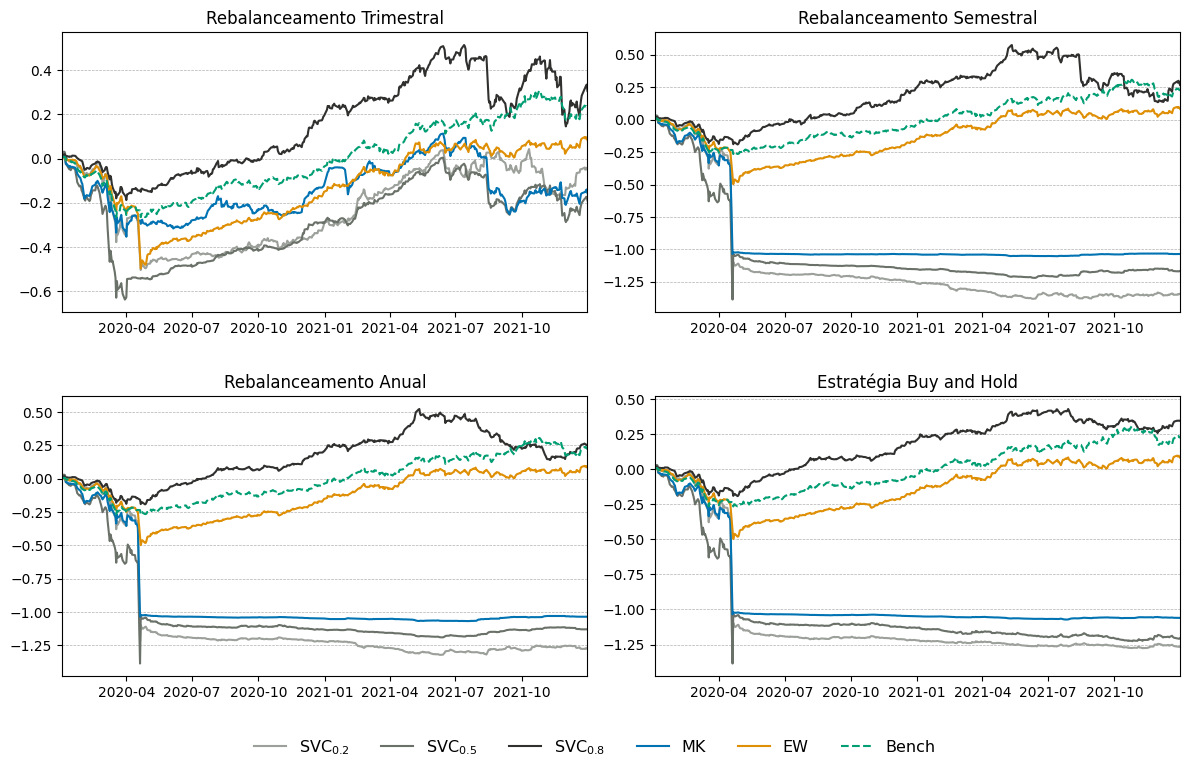

In [140]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

periodos = [
    ("Rebalanceamento Trimestral", cumulative_returns_svc_trimestral, cumulative_return_mk_trimestral, cumulative_return_equal_trimestral, cumulative_return_bench_trimestral),
    ("Rebalanceamento Semestral", cumulative_returns_svc_semestral, cumulative_return_mk_semestral, cumulative_return_equal_semestral, cumulative_return_bench_semestral),
    ("Rebalanceamento Anual", cumulative_returns_svc_anual, cumulative_return_mk_anual, cumulative_return_equal_anual, cumulative_return_bench_anual),
    ("Estratégia Buy and Hold", cumulative_returns_svc_buyandhold, cumulative_return_mk_buyandhold, cumulative_return_equal_buyandhold, cumulative_return_bench_buyandhold)
]

handles = None
labels = None
xmin = cumulative_return_mk_trimestral.index.min()
xmax = cumulative_return_mk_trimestral.index.max()

for ax, (titulo, svc, mk, ew, bench) in zip(axs.flatten(), periodos):

    l1, = ax.plot(svc[0.2], label='SVC$_{0.2}$', color=cor1)
    l2, = ax.plot(svc[0.5], label='SVC$_{0.5}$', color=cor2)
    l3, = ax.plot(svc[0.8], label='SVC$_{0.8}$', color=cor3)
    l4, = ax.plot(mk, label='MK')
    l5, = ax.plot(ew, label='EW')
    l6, = ax.plot(bench, label='Bench', linestyle='--')

    ax.set_title(titulo)
    ax.set_xlim(xmin, xmax)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.5)

    if handles is None:
        handles = [l1, l2, l3, l4, l5, l6]
        labels = [h.get_label() for h in handles]
plt.xlim(cumulative_return_mk_trimestral.index.min(), cumulative_return_mk_trimestral.index.max())

fig.legend(handles, labels,
           loc='lower center',
           ncol=6,
           frameon=False,
           fontsize=11.5,
           bbox_to_anchor=(0.5, 0.03))

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.subplots_adjust(hspace=0.3)
plt.savefig('retornos_acumulados_sbbd.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

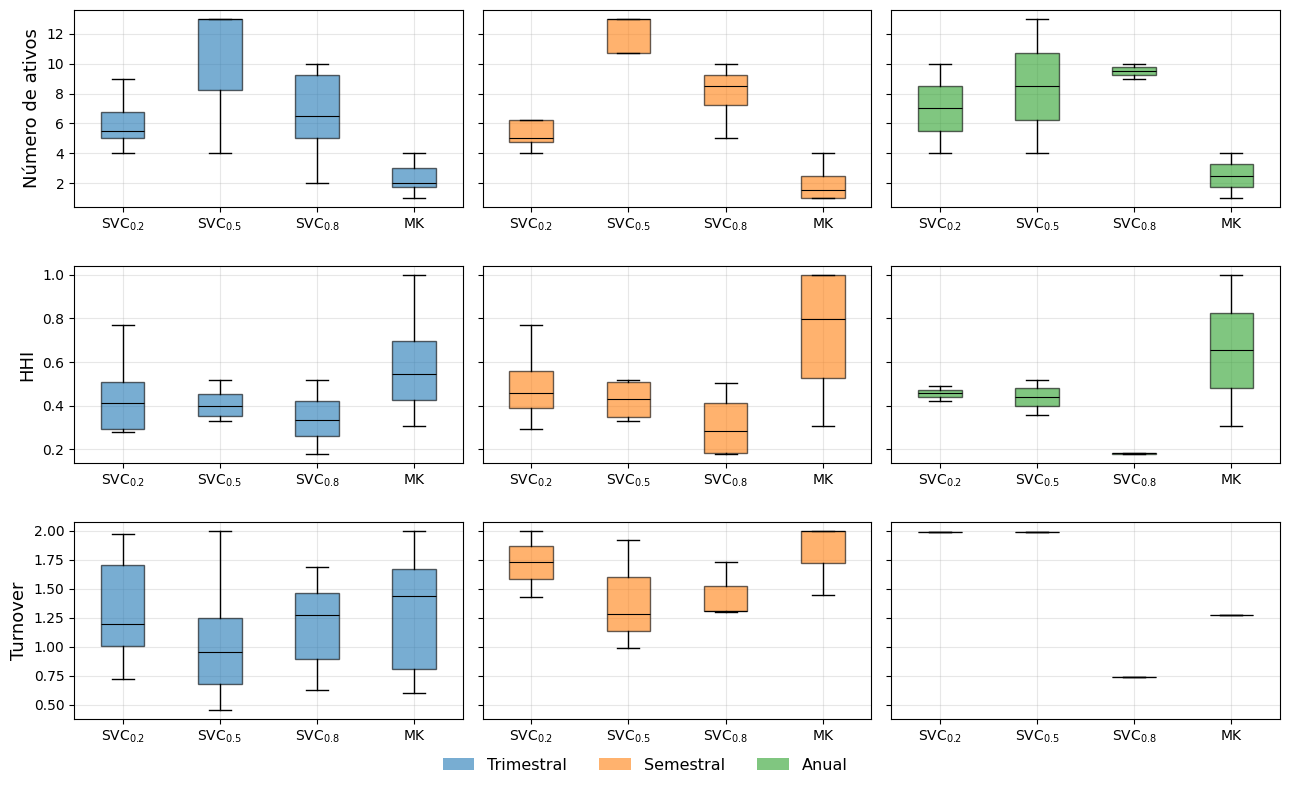

In [141]:
medidas = [
    [diversity_trimestral, diversity_semestral, diversity_anual],
    [hhi_trimestral, hhi_semestral, hhi_anual],
    [turnover_trimestral, turnover_semestral, turnover_anual]
]

titulos_linha = ['Número de ativos', 'HHI', 'Turnover']
tempos = ['Trimestral','Semestral','Anual']
cores = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(3, 3, figsize=(13, 9), sharey='row')

for i in range(3):      
    for j in range(3):  
        df = medidas[i][j]
        ax = axes[i, j]
        data = [df[col].dropna() for col in df.columns]
        bp = ax.boxplot(data, patch_artist=True, showfliers=False, medianprops=dict(color='black', linewidth=0.8))
        for box in bp['boxes']:
            box.set(facecolor=cores[j], alpha=0.6)
        ax.set_xticks(range(1, len(df.columns)+1))
        ax.set_xticklabels(df.columns)
        ax.grid(alpha=0.3)
        ax.set_title("")
        if j == 0:
            ax.set_ylabel(titulos_linha[i], fontsize=13)

legend_elements = [Patch(facecolor=cores[i], alpha=0.6, label=tempos[i]) for i in range(3)]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11.5, frameon=False, bbox_to_anchor=(0.5, 0.05))

plt.tight_layout(rect=[0,0.08,1,0.93])
plt.subplots_adjust(hspace=0.3)
plt.savefig('medidas_dispersao_sbbd.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()